<div class="alert alert-block" style="background-color: #51585eff; border-color: #42474aff; color: white;">
<center> <h1> Syntravel - Travel Diaries Generation </h1> </center> <br>
<center> <h2> Survey EDA </h2></center>


# Tabel of Contents

**1. [Importing Libraries and Loading Data](#importing-libraries-and-data)**  
   - [1.1 Importing Libraries](#importing-libraries)  
   - [1.2 Loading and Reading Data](#loading-and-reading-data)  

**2. [Internal Transferability](#internal)**
   - [2.1 Utrecht ](#utrecht)  
   - [2.2 Friesland](#Friesland)
   - [2.3 Results Analysis](#results)

**3. [External Transferability](#external)**
   - [3.1 Portguese Travel Diaries Generation](#gene)  
   - [3.2 Results EDA](#eda)

# 1. Importing Libraries and Loading Data  <a class="anchor" id="importing-libraries-and-data"></a>


## 1.1. Importing Libraries <a class="anchor" id="importing-libraries"></a>

In [11]:
import os
if not os.path.isdir('llm_config'):
    os.chdir('..')

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
import collections

# Functions
from Helpers.visualizations.fig_survey import *

## 1.2. Loading and Reading Data <a class="anchor" id="loading-and-reading-data"></a>


In [12]:
long_df = load_survey_long()
compute_survey_summary(long_df)

n_respondents                   62.000000
n_ratings                      992.000000
overall_accuracy                 0.463710
accuracy_on_real                 0.431452
accuracy_on_synthetic            0.495968
mean_plausibility_real           2.792339
mean_plausibility_synthetic      3.060484
dtype: float64

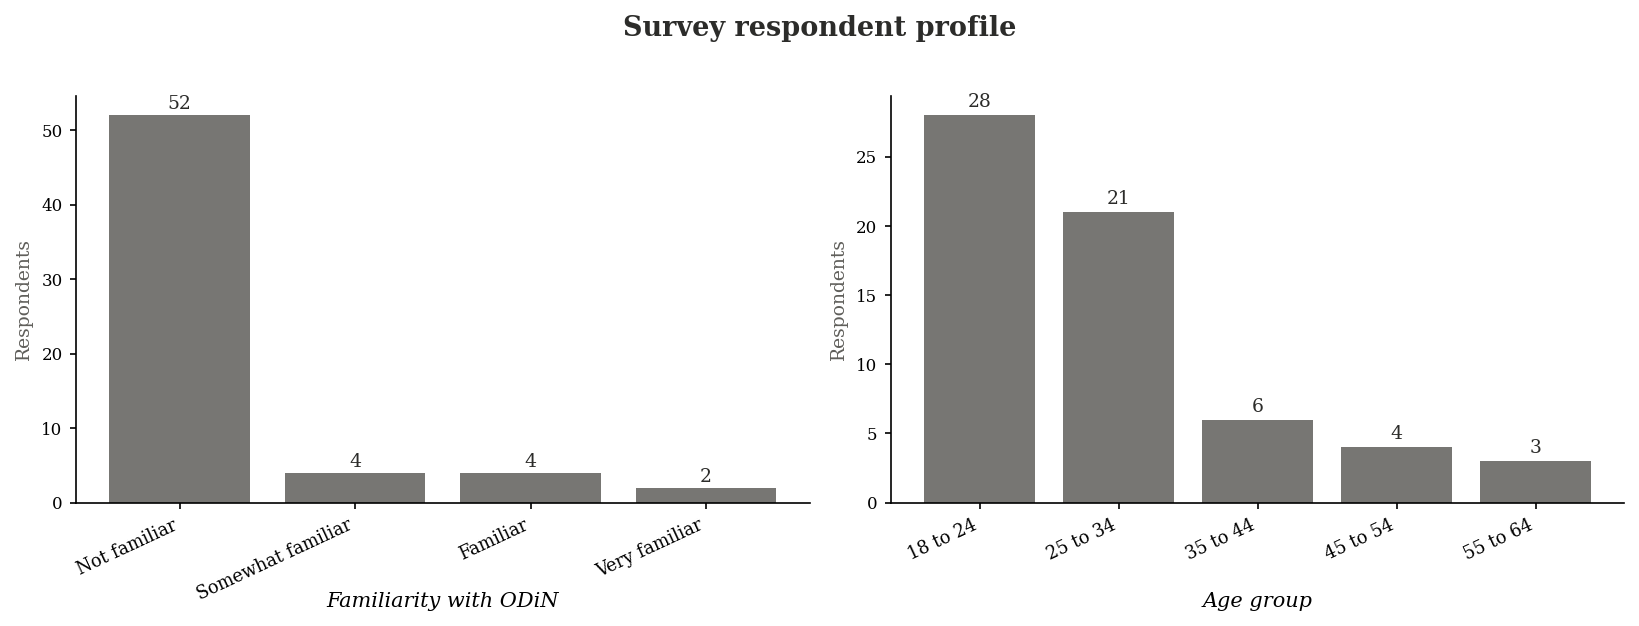

In [13]:
plot_respondent_demographics(long_df)

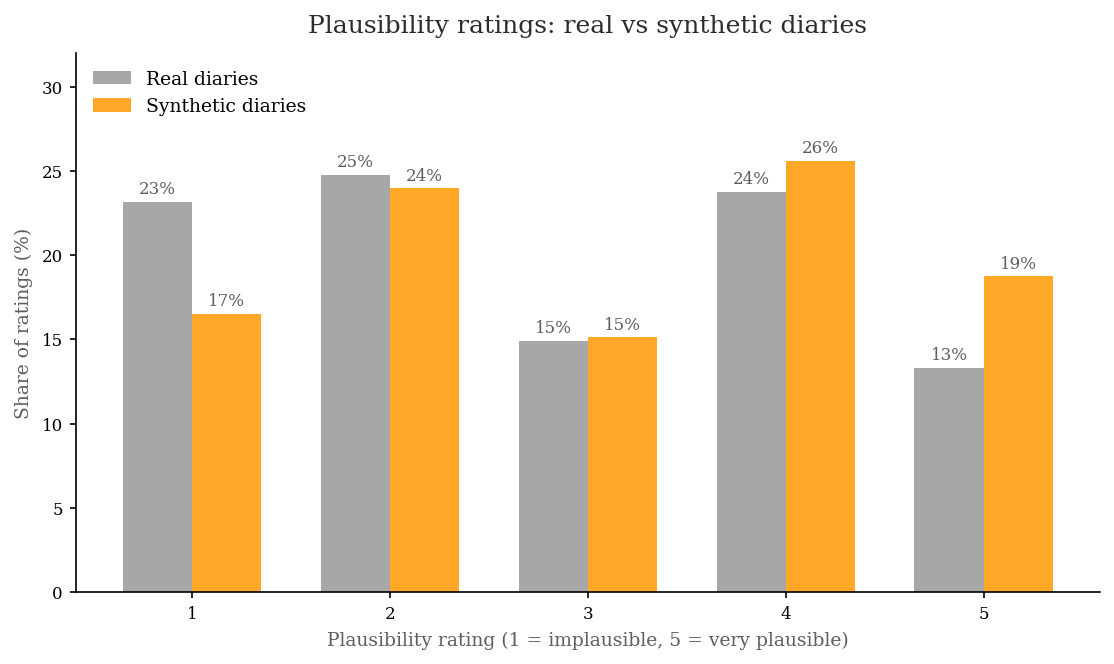

In [14]:
plot_plausibility_distribution(long_df)

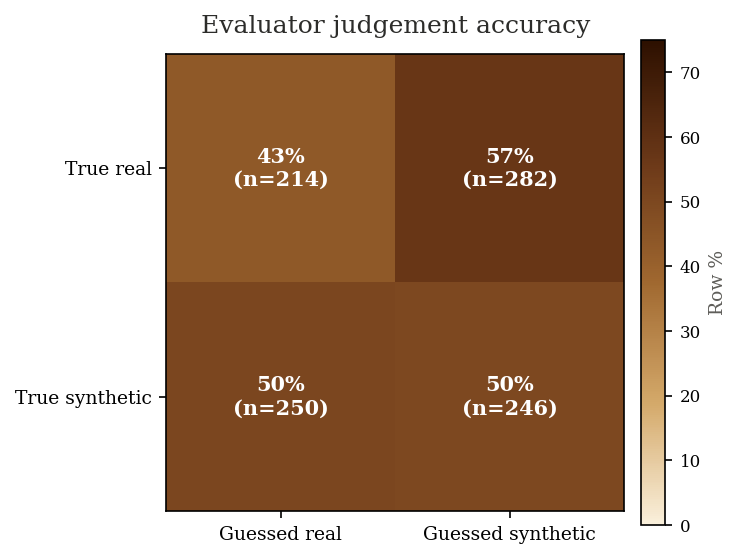

In [15]:
plot_confusion_matrix(long_df)

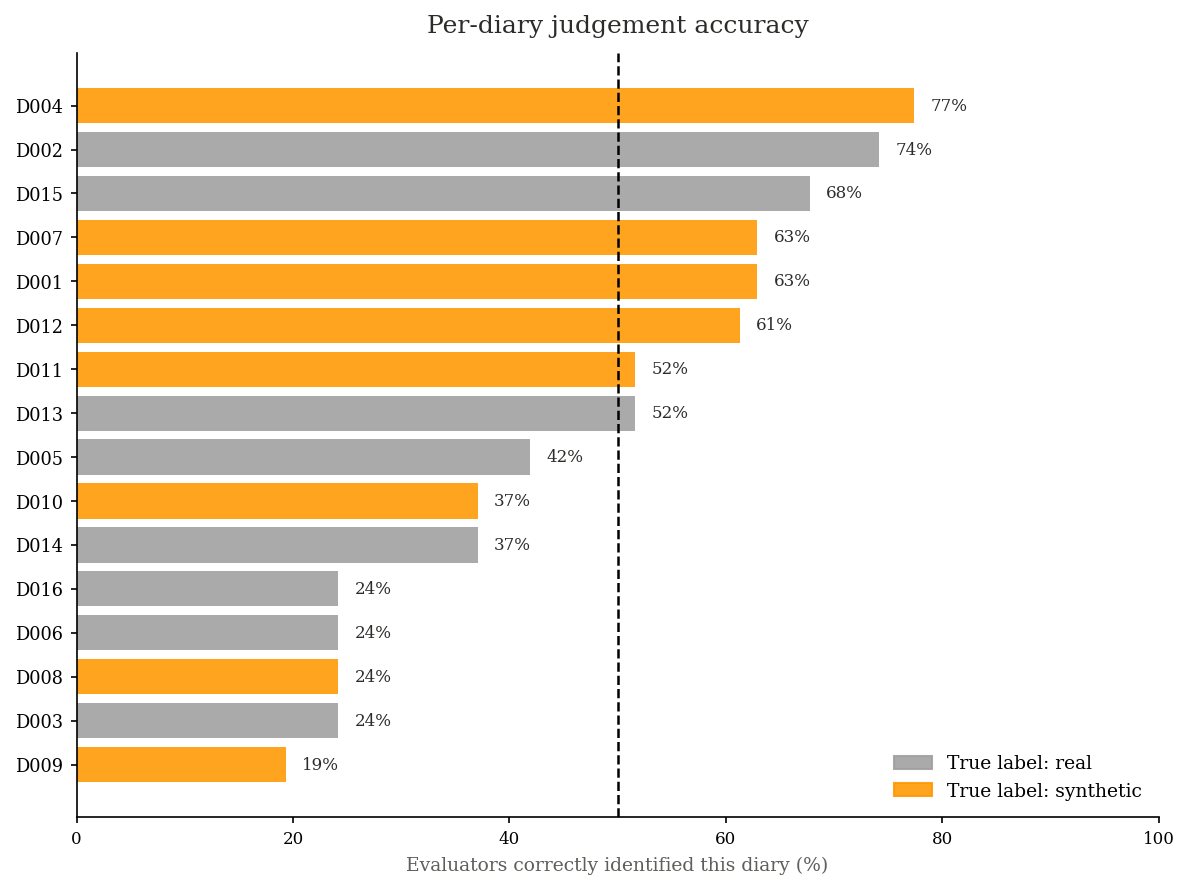

In [16]:
plot_per_diary_accuracy(long_df)

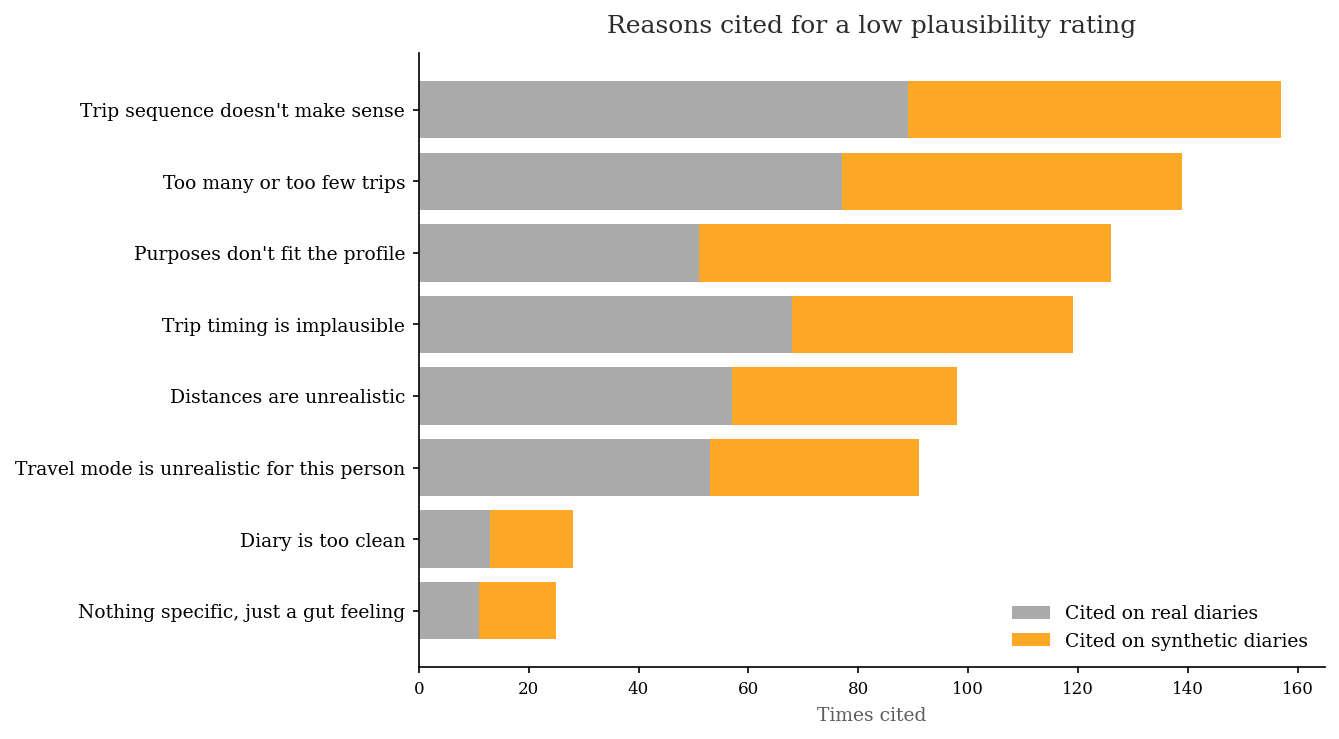

In [17]:
plot_implausibility_reasons(long_df)

# 2. Statistical Tests

Three pre-registered tests on the 62-respondent, 992-rating dataset (`long_df` loaded above):

1. **Discrimination accuracy vs chance** — one-sided binomial test on pooled real/synthetic guesses.
2. **Plausibility, real vs synthetic** — Mann–Whitney U + rank-biserial effect size.
3. **Reason code "purposes don't fit the profile"** — chi-square (one pre-identified cue, not corrected across all eight reasons).

## 2.1. Discrimination Accuracy vs Chance <a class="anchor" id="binomial"></a>

In [18]:
from scipy.stats import binomtest

# Pooled across all respondents x diaries: can evaluators tell real from
# synthetic at better-than-chance accuracy? The theoretically interesting
# outcome for this thesis is FAILURE to exceed chance (accuracy <= 50%),
# since that is evidence the synthetic diaries are behaviourally plausible.
sub = long_df.dropna(subset=["correct"])
n_total = len(sub)
n_correct = int(sub["correct"].sum())
acc = n_correct / n_total

binom_result = binomtest(n_correct, n_total, p=0.5, alternative="greater")
# Two-sided CI for reporting accuracy (the test itself stays one-sided above;
# a CI inherited from the one-sided test would report an uninformative 100% upper bound).
ci = binomtest(n_correct, n_total, p=0.5, alternative="two-sided").proportion_ci(confidence_level=0.95)

print(f"n correct / n total: {n_correct} / {n_total}")
print(f"accuracy: {acc * 100:.1f}%")
print(f"p-value (one-sided, H1: accuracy > 50%): {binom_result.pvalue:.3f}")
print(f"95% CI on accuracy: [{ci.low * 100:.1f}%, {ci.high * 100:.1f}%]")
print()

verdict = "not above chance" if binom_result.pvalue >= 0.05 else "above chance"
print(f"Binomial: {acc * 100:.1f}% correct ({n_correct}/{n_total}), "
      f"p = {binom_result.pvalue:.3f} — {verdict}.")

n correct / n total: 460 / 992
accuracy: 46.4%
p-value (one-sided, H1: accuracy > 50%): 0.990
95% CI on accuracy: [43.2%, 49.5%]

Binomial: 46.4% correct (460/992), p = 0.990 — not above chance.


## 2.2. Plausibility: Real vs Synthetic <a class="anchor" id="mannwhitney"></a>

In [19]:
from scipy.stats import mannwhitneyu

plaus = long_df.dropna(subset=["plausibility", "true_label"])
real_plaus = plaus.loc[plaus["true_label"] == "real", "plausibility"]
syn_plaus  = plaus.loc[plaus["true_label"] == "synthetic", "plausibility"]

u_stat, mw_pvalue = mannwhitneyu(syn_plaus, real_plaus, alternative="two-sided")
n_syn, n_real = len(syn_plaus), len(real_plaus)
r_rank_biserial = 1 - (2 * u_stat) / (n_syn * n_real)

print(f"real:      mean = {real_plaus.mean():.2f}, median = {real_plaus.median():.1f}, n = {n_real}")
print(f"synthetic: mean = {syn_plaus.mean():.2f}, median = {syn_plaus.median():.1f}, n = {n_syn}")
print(f"U = {u_stat:.1f}, p = {mw_pvalue:.3f}, rank-biserial r = {r_rank_biserial:.2f}")
print()

print(f"Mann–Whitney: real mean {real_plaus.mean():.2f} / synthetic {syn_plaus.mean():.2f}, "
      f"U = {u_stat:.0f}, p = {mw_pvalue:.3f}, r = {r_rank_biserial:.2f}.")

real:      mean = 2.79, median = 3.0, n = 496
synthetic: mean = 3.06, median = 3.0, n = 496
U = 136519.5, p = 0.002, rank-biserial r = -0.11

Mann–Whitney: real mean 2.79 / synthetic 3.06, U = 136520, p = 0.002, r = -0.11.


## 2.3. Reason Code: "Purposes Don't Fit the Profile" <a class="anchor" id="chisquare"></a>

In [20]:
from scipy.stats import chi2_contingency, fisher_exact

REASON = "Purposes don't fit the profile"

reason_df = long_df.copy()
reason_df["cited"] = reason_df["reasons"].apply(lambda rs: REASON in rs)

reason_table = pd.crosstab(reason_df["true_label"], reason_df["cited"])
reason_table = reason_table.reindex(index=["real", "synthetic"], columns=[False, True], fill_value=0)
reason_table.columns = ["not cited", "cited"]

chi2, chi2_pvalue, dof, expected = chi2_contingency(reason_table)

print(reason_table)
print()
print(f"chi2({dof}) = {chi2:.2f}, p = {chi2_pvalue:.3f}")

# This is one pre-identified cue (Q2's "purposes don't fit the profile"
# checkbox); we are not correcting across all eight reason options since
# only this one was flagged in advance for testing.
if (expected < 5).any():
    _, fisher_pvalue = fisher_exact(reason_table)
    print(f"Fisher's exact p = {fisher_pvalue:.3f} (an expected cell < 5)")
print()

print(f"Chi-square (purposes-fit-profile): χ²({dof}) = {chi2:.2f}, p = {chi2_pvalue:.3f}.")

            not cited  cited
true_label                  
real              445     51
synthetic         421     75

chi2(1) = 4.81, p = 0.028

Chi-square (purposes-fit-profile): χ²(1) = 4.81, p = 0.028.
